<a href="https://colab.research.google.com/github/riggij-sys/Jake-Riggi-Repository/blob/main/coding_homework_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Jake Riggi
*Neur 265*

**Apr 1, 2025**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#this imports our module

In [ ]:
url='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial1.csv'
spikes_left_trial1=np.loadtxt(url, delimiter=',')
url2='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial1.csv'
spikes_right_trial1=np.loadtxt(url2, delimiter=',')
url3='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial2.csv'
spikes_left_trial2=np.loadtxt(url3, delimiter=',')
url4='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial2.csv'
spikes_right_trial2=np.loadtxt(url4, delimiter=',')
#this inputs all of the spikes during the waiting period

In [ ]:
print(len(spikes_left_trial1))
print(len(spikes_right_trial1))
print(len(spikes_left_trial2))
print(len(spikes_right_trial2))
#this cell prints the number of total spikes in both of our conditions, left vs right

65
45
53
69


In [ ]:
len_waitingperiod=30
print(len(spikes_left_trial1)/len_waitingperiod)
print(len(spikes_right_trial1)/len_waitingperiod)
print(len(spikes_left_trial2)/len_waitingperiod)
print(len(spikes_right_trial2)/len_waitingperiod)
#this creates firing rate for all of these conditons

2.1666666666666665
1.5
1.7666666666666666
2.3


It is difficult to determine if there is a difference in firing rates in this neuron between our conditions, whether or not the mouse is turning right or left





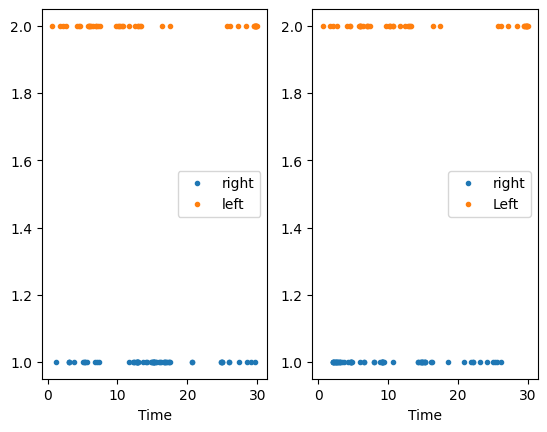

In [ ]:
fig, ax = plt.subplots(1,2)
ax[0].plot(spikes_left_trial1, np.ones_like(spikes_left_trial1), '.')
ax[0].plot(spikes_right_trial1, 2 * np.ones_like(spikes_right_trial1), '.')
ax[1].plot(spikes_right_trial2, np.ones_like(spikes_right_trial2), '.')
ax[1].plot(spikes_right_trial1, 2 * np.ones_like(spikes_right_trial1), '.')
ax[0].set_xlabel('Time')
ax[1].set_xlabel('Time')
ax[0].legend({'Right',"Left"})
ax[1].legend({'Left', 'Right'})
#this cell creates two subplots showing when the spikes are throughout the trial



I think that the right side seems to be more bursty than the left side in this neuron

In [ ]:
ISIsleft1=np.diff(spikes_left_trial1)
ISIsright1=np.diff(spikes_right_trial1)
ISIsleft2=np.diff(spikes_left_trial2)
ISIsright2=np.diff(spikes_right_trial2)
#calculates ISI arrays for each of our condition

Text(0, 0.5, 'Counts')

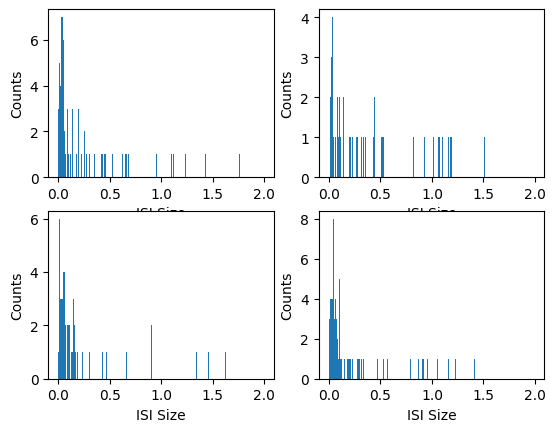

In [ ]:
bins=np.arange(0,2,.01)
fig, ax = plt.subplots(2,2)
ax[0,0].hist(ISIsleft1,bins)
ax[0,0].set_xlabel('ISI Size')
ax[0,0].set_ylabel('Counts')
ax[0,1].hist(ISIsright1,bins)
ax[0,1].set_xlabel('ISI Size')
ax[0,1].set_ylabel('Counts')
ax[1,0].hist(ISIsleft2,bins)
ax[1,0].set_xlabel('ISI Size')
ax[1,0].set_ylabel('Counts')
ax[1,1].hist(ISIsright2,bins)
ax[1,1].set_xlabel('ISI Size')
ax[1,1].set_ylabel('Counts')
#this cell creates 4 histograms of the different counts of different ISIs to roughly measure burstiness

This neuron in general doesn't seem to be very bursty, as most of the ISIs across right vs left condition and across trial 1 and 2. However, there seems to more ISI variation in the neuron when the mouse is about to turn left, so we can say it is more bursty before turning left

Text(0, 0.5, 'Time [s]')

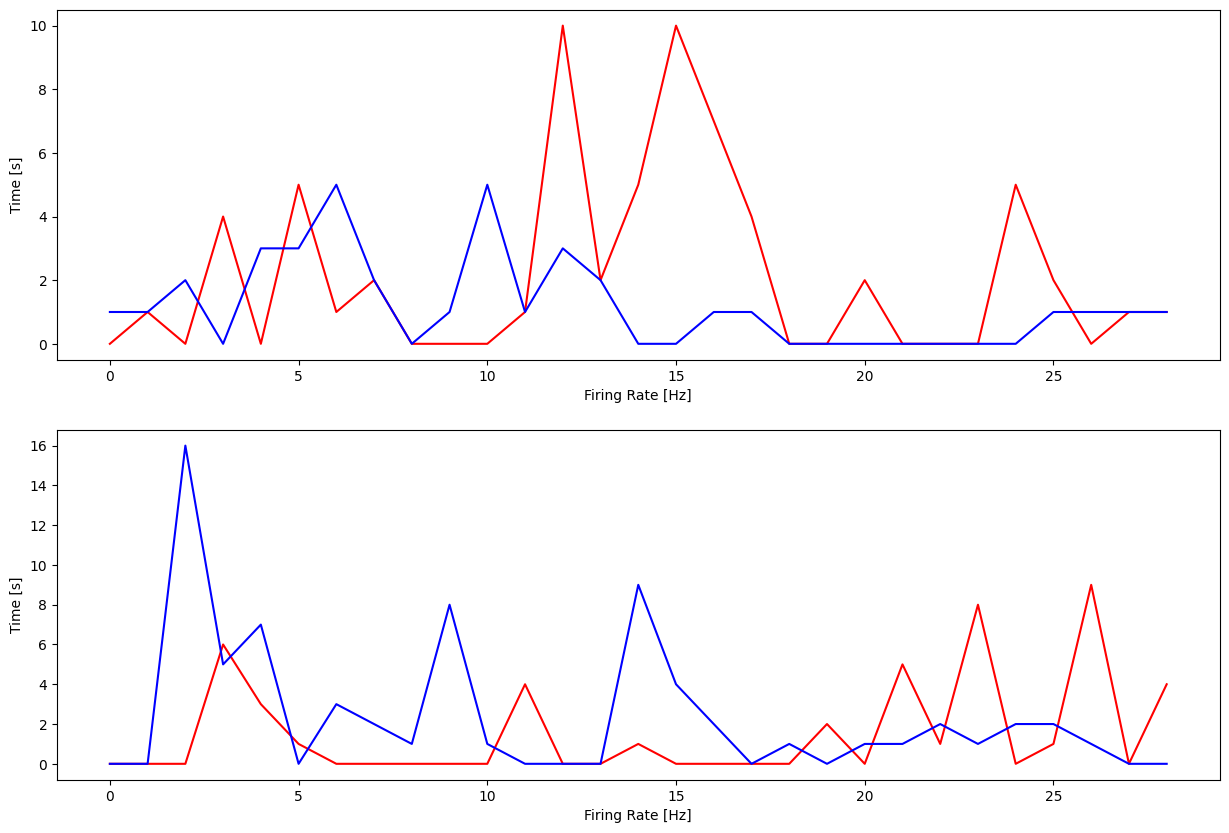

In [ ]:
binsize=1
time_bins=np.arange(0,30,binsize)
fr_left1 = np.zeros(len(time_bins)-1)
for i in range(len(time_bins)-1):
  spk_index = (spikes_left_trial1 > time_bins[i]) & (spikes_left_trial1 < time_bins[i+1])
  true_values = spikes_left_trial1[spk_index]
  fr_left1[i] = (len(true_values))/binsize


binsize=1
time_bins=np.arange(0,30,binsize)
fr_right1 = np.zeros(len(time_bins)-1)
for i in range(len(time_bins)-1):
  spk_index = (spikes_right_trial1 > time_bins[i]) & (spikes_right_trial1 < time_bins[i+1])
  true_values = spikes_right_trial1[spk_index]
  fr_right1[i] = (len(true_values))/binsize

binsize=1
time_bins=np.arange(0,30,binsize)
fr_left2 = np.zeros(len(time_bins)-1)
for i in range(len(time_bins)-1):
  spk_index = (spikes_left_trial2 > time_bins[i]) & (spikes_left_trial2 < time_bins[i+1])
  true_values = spikes_left_trial2[spk_index]
  fr_left2[i] = (len(true_values))/binsize


binsize=1
time_bins=np.arange(0,30,binsize)
fr_right2 = np.zeros(len(time_bins)-1)
for i in range(len(time_bins)-1):
  spk_index = (spikes_right_trial2 > time_bins[i]) & (spikes_right_trial2 < time_bins[i+1])
  true_values = spikes_right_trial2[spk_index]
  fr_right2[i] = (len(true_values))/binsize

fig, ax = plt.subplots(2,1, figsize=(15,10))
ax[0].plot(time_bins[:-1],fr_left1, color='red')
ax[0].plot(time_bins[:-1],fr_right1,color='blue')
ax[0].set_xlabel('Firing Rate [Hz]')
ax[0].set_ylabel('Time [s]')
ax[1].plot(time_bins[:-1],fr_left2, color='red')
ax[1].plot(time_bins[:-1],fr_right2,color='blue')
ax[1].set_xlabel('Firing Rate [Hz]')
ax[1].set_ylabel('Time [s]')
#this code cell calculates firing rate over time for all 4 of our conditions and plots trial one in the top chart and trial two in the bottom

Very generlly, it seems as if this neuron has a higher firing rate early when the mouse is turning right and has a higher firing rate leter when the mouse is turning left. Looking at this chart, it seems when the mouse was turning left in the first trial it had a high firing rate but a low firing rate in the second. This trend is swapped when the mouse is turning right. In terms of specific timepoints of high firing rate, this is difficult, but 5 seconds for right-turn and 25 seconds for left-turn seems to be accurate